In [44]:
import pandas as pd
import scipy.stats
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import TargetEncoder
from concurrent.futures import ThreadPoolExecutor
import itertools
import gc
from lightgbm import LGBMClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import warnings
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.base import clone
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings("ignore")

We use an unconventional naming scheme here: 
- training
- testing
- out-of-time validation set

We leave the validation set out for real out-of-time validation, and for the rest, we apply a k-fold cv.

We unfortunately only have a full year of data. Ideally, we would want to have at least one year of data in the training + testing partition to have the model to learn through seasonality. 

However, given the circumstance, we would have to compromise on this and leave some of the months for real out-of-time validation set for true out-of-sample validation.

### Data Prep

In [32]:
df = pd.read_parquet('data/candidate_variables.parquet')
df.Date.min(), df.Date.max()

(Timestamp('2010-01-15 00:00:00'), Timestamp('2010-12-31 00:00:00'))

In [33]:
df_oot = df[df.Date >= '2010-11-01']
df_train_test = df[df.Date < '2010-11-01']

In [34]:
selected_features = pd.read_csv('data/selected_features_ks.csv')
TOP_NVAR = 18
selected_features = selected_features['feature'].tolist()[:TOP_NVAR]

In [35]:
selected_features

['Cardnum_unique_count_for_card_state_1',
 'card_merchdesc_state_total_14',
 'card_dow_count_1_by_30',
 'merchnum_desc_total_1',
 'card_zip3_total_30',
 'card_merchdesc_zip_max_60',
 'card_dow_unique_count_for_Merchnum_1',
 'card_merchdesc_zip_actual/med_60',
 'card_merchnum_state_total_amount_1_by_60',
 'card_dow_count_0_by_30_sq',
 'card_dow_count_0_by_30',
 'card_dow_count_1_by_30_sq',
 'card_dow_vdratio_0by30',
 'card_dow_vdratio_1by30',
 'Cardnum_vdratio_1by7',
 'card_dow_unique_count_for_merch_state_1',
 'card_dow_unique_count_for_card_merchnum_state_3',
 'card_dow_unique_count_for_card_merch_3']

The model building pipeline is delineated as follows:

1. Robust Scaler
2. Clip outliers
3. Standard Scaler
4. PCA (Optional)
5. Model building

### Exploratory Analysis for PCA

Before we do that, though, we should implement exploratory analysis and visualize variance as a function of number of components.

In [36]:
X_train_test = df_train_test[selected_features]
y_train_test = df_train_test['Fraud']
X_oot = df_oot[selected_features]
y_oot = df_oot['Fraud']

In [37]:
CLIP_THRESHOLD = 10

robust_scaler = RobustScaler()
X_robust = robust_scaler.fit_transform(X_train_test)

X_clipped = np.clip(X_robust, -CLIP_THRESHOLD, CLIP_THRESHOLD)

standard_scaler = StandardScaler()
X_scaled = standard_scaler.fit_transform(X_clipped)

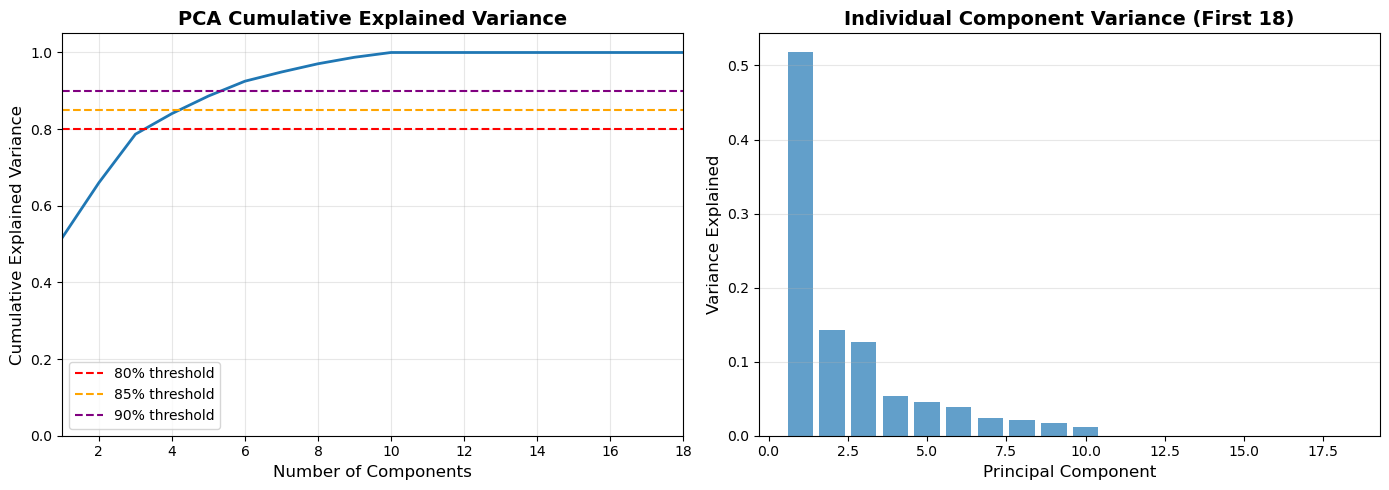

In [38]:
pca_full = PCA()
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
ax1.plot(range(1, len(cumsum_var) + 1), cumsum_var, linewidth=2)
ax1.axhline(y=0.80, color='r', linestyle='--', label='80% threshold', linewidth=1.5)
ax1.axhline(y=0.85, color='orange', linestyle='--', label='85% threshold', linewidth=1.5)
ax1.axhline(y=0.90, color='purple', linestyle='--', label='90% threshold', linewidth=1.5)
ax1.set_xlabel('Number of Components', fontsize=12)
ax1.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax1.set_title('PCA Cumulative Explained Variance', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_xlim(1, len(cumsum_var))
ax1.set_ylim(0, 1.05)

ax2 = axes[1]
n_bars = min(18, len(pca_full.explained_variance_ratio_))
ax2.bar(range(1, n_bars + 1), pca_full.explained_variance_ratio_[:n_bars], alpha=0.7)
ax2.set_xlabel('Principal Component', fontsize=12)
ax2.set_ylabel('Variance Explained', fontsize=12)
ax2.set_title(f'Individual Component Variance (First {n_bars})', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Model Building

#### Fraud Detection Rate

Let $N$ be the total number of transactions.

Let $y_i \in \{0, 1\}$ be the true label for transaction $i$, where $1$ is fraud and $0$ is not fraud.

Let $r$ be the detection rate (e.g., $r = 0.03$ for 3%).

Let $k = \lceil N \times r \rceil$ be the number of transactions we are investigating (the top 3%).

Let $S_k$ be the set of indices of the $k$ transactions with the *highest predicted probabilities* of fraud.

The Fraud Detection Rate at rate $r$ is calculated as the number of actual frauds within our top $k$ predictions divided by the total number of actual frauds in the entire dataset:

$$\text{FDR@}r = \frac{\sum_{i \in S_k} y_i}{\sum_{i=1}^{N} y_i}$$

In [39]:
def calculate_fdr_at_rate(y_true, y_pred_proba, detect_rate=0.03):
    n_top = int(round(len(y_true) * detect_rate))
    top_indices = np.argpartition(y_pred_proba, -n_top)[-n_top:]
    return y_true.iloc[top_indices].sum() / y_true.sum()

def evaluate_model_cv(X_train_test, y_train_test, X_oot, y_oot, model,
                      n_splits=5, detect_rate=0.03, use_pca=False, n_components=None,
                      use_standard_scaler=True):
    """
    Returns DataFrame with FDR scores for each fold
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_test)):
        X_train, X_val = X_train_test.iloc[train_idx], X_train_test.iloc[val_idx]
        y_train, y_val = y_train_test.iloc[train_idx], y_train_test.iloc[val_idx]
        
        steps = [
            ('robust', RobustScaler()),
            ('clip', FunctionTransformer(func=np.clip, kw_args={'a_min': -10, 'a_max': 10}))
        ]
        if use_standard_scaler:
            steps.append(('standard', StandardScaler()))
        if use_pca:
            steps.append(('pca', PCA(n_components=n_components)))
        steps.append(('model', clone(model)))
        
        pipeline = Pipeline(steps)
        
        pipeline.fit(X_train, y_train.values.ravel())
        
        fdr_train = calculate_fdr_at_rate(y_train, pipeline.predict_proba(X_train)[:, 1], detect_rate)
        fdr_val = calculate_fdr_at_rate(y_val, pipeline.predict_proba(X_val)[:, 1], detect_rate)
        fdr_oot = calculate_fdr_at_rate(y_oot, pipeline.predict_proba(X_oot)[:, 1], detect_rate)
        
        results.append({'fold': fold, 'train': fdr_train, 'val': fdr_val, 'oot': fdr_oot})
        print(f"Fold {fold}: Train={fdr_train:.3f}, Val={fdr_val:.3f}, OOT={fdr_oot:.3f}")
    
    results_df = pd.DataFrame(results)
    
    print(f"\nMean FDR: Train={results_df['train'].mean():.3f}, "
          f"Val={results_df['val'].mean():.3f}, OOT={results_df['oot'].mean():.3f}")
    
    return results_df

In [41]:
results_log_reg = evaluate_model_cv(
    X_train_test, 
    y_train_test,
    X_oot,
    y_oot,
    model=LogisticRegression(),
    n_splits=5,
    detect_rate=0.03
    )

Fold 0: Train=0.585, Val=0.584, OOT=0.469
Fold 1: Train=0.582, Val=0.580, OOT=0.469
Fold 2: Train=0.588, Val=0.574, OOT=0.463
Fold 3: Train=0.586, Val=0.583, OOT=0.469
Fold 4: Train=0.581, Val=0.596, OOT=0.466

Mean FDR: Train=0.584, Val=0.583, OOT=0.467


In [43]:
results_dt = evaluate_model_cv(
    X_train_test, 
    y_train_test,
    X_oot,
    y_oot,
    model=DecisionTreeClassifier(random_state=42, criterion='gini', splitter='best', max_depth=10, min_samples_leaf=100, min_samples_split=200),
    n_splits=5,
    detect_rate=0.03
    )

Fold 0: Train=0.673, Val=0.657, OOT=0.531
Fold 1: Train=0.676, Val=0.654, OOT=0.517
Fold 2: Train=0.686, Val=0.620, OOT=0.534
Fold 3: Train=0.679, Val=0.654, OOT=0.537
Fold 4: Train=0.670, Val=0.682, OOT=0.539

Mean FDR: Train=0.677, Val=0.653, OOT=0.531


In [45]:
results_random_forest = evaluate_model_cv(
    X_train_test,
    y_train_test,
    X_oot,
    y_oot,
    model=RandomForestClassifier(random_state=42, n_estimators=20, criterion='gini', max_depth=10, min_samples_leaf=80, max_features=8),
    n_splits=5,
    detect_rate=0.03
    )

Fold 0: Train=0.689, Val=0.665, OOT=0.542
Fold 1: Train=0.684, Val=0.680, OOT=0.565
Fold 2: Train=0.699, Val=0.650, OOT=0.551
Fold 3: Train=0.693, Val=0.666, OOT=0.542
Fold 4: Train=0.678, Val=0.695, OOT=0.542

Mean FDR: Train=0.689, Val=0.671, OOT=0.548
